In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# CDF analysis of ProvedIt dataset

This notebook computes per-dye probability density functions (PDF) and cumulative distribution functions (CDF) of electropherogram (EPG) intensities for the ProvedIt dataset. It uses the existing `CustomHIDDataset` to iterate over HID files and aggregates the distributions across the dataset and for each dye separately.

In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

from DNAnet.evaluation.visualizations import DNA_CHANNELS, GF_DYE_NAMES
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.data_models.hid_dataset import HIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard

from visualization.histograms import compute_histograms, find_allele_peaks, find_false_negative_peaks, find_predicted_peaks, find_predicted_peaks_by_type, aggregate_histograms

## Load ProvedIt dataset
Update the `hid_files_path` variable to point to the directory containing the ProvedIt HID files.

In [3]:
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"

# In this file we very simply load a ProvedIt dataset, then visualize the first element
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

gf_dataset = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

len(gf_dataset)

2025-08-18 16:21:08 INFO     Found 675 files in /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles
2025-08-18 16:21:09 WARNING  Size standard for E04_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid differs 18.912544484957948 from the expected 
2025-08-18 16:21:12 WARNING  Size standard for H08_RD14-0003-49_50_29-1,4,1-M2e-0.378GF-Q1.4_08.5sec.hid differs 13.401428160223645 from the expected 
2025-08-18 16:21:14 WARNING  Size standard for G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid differs 12.982847650856456 from the expected 
2025-08-18 16:21:17 WARNING  Size standard for E03_RD14-0003-48_49_50_29-1,4,4,4-M2I15-0.75GF-Q1.1_05.5sec.hid differs 13.001695302289932 from the expected 
2025-08-18 16:21:18 WARNING  Size standard for E05_RD14-0003-46_47_48-1,1,1-M3I35-0.189GF-QLAND_05.5sec.hid differs 18.824515396807158 from the expected 
2025-08-18 16:21:26 INFO     Number of valid images: 670
2025-08-18 16:21:26 INFO     

670

In [4]:
nfi_dataset = HIDDataset(
  root="resources/data/2p_5p_Dataset_NFI/Raw data .HID files",
  panel="resources/data/SGPanel_PPF6C_SPOOR.xml",
  annotations_path="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam",
  hid_to_annotations_path="resources/data/2p_5p_Dataset_NFI/2p_5p_hid_to_annotation.csv",
  shuffle=False,
  ground_truth_as_annotations=False,
)

len(nfi_dataset)

2025-08-18 16:21:26 INFO     Loading data from file
2025-08-18 16:21:26 INFO     Walking directory to retrieve all hid files...
Processing folders: 100%|██████████| 21/21 [00:00<00:00, 2069.41it/s]
2025-08-18 16:21:26 INFO     Found 350 HIDs
2025-08-18 16:21:26 INFO     Found 0 HIDs without ladder
2025-08-18 16:21:26 INFO     Removed 0 HIDs without annotation
Loading data from resources/data/2p_5p_Dataset_NFI/Raw data .HID files:   0%|          | 0/350 [00:00<?, ?it/s]2025-08-18 16:21:26 WARNING  Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G03_21
Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G03_21
Loading data from resources/data/2p_5p_Dataset

350

## Predict

In [5]:
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
unet_model.load("best_model_analysis_on_hard_files/")
predictions = unet_model.predict_batch(gf_dataset)
predictions = np.array(predictions)

2025-08-18 16:21:58 INFO     Using device: cpu


2025-08-18 16:25:36 INFO     Calling alleles from predicted segmentation...
2025-08-18 16:25:37 WARNING  No predictions present in dye row 0
2025-08-18 16:25:40 WARNING  No predictions present in dye row 1


# Aggregate PDFs and CDFs over separate dye lanes for the whole dataset
This cell iterates over all images, accumulating histogram counts per dye. The counts are then normalised to obtain the aggregated PDFs and CDFs.

In [106]:
output_dir = Path("figures")
bins = 128
gf_agg_counts, gf_agg_pdf, gf_agg_cdf, bin_edges = aggregate_histograms(gf_dataset, bins=bins)
nfi_agg_counts, nfi_agg_pdf, nfi_agg_cdf, bin_edges = aggregate_histograms(nfi_dataset, bins=bins)

## Plot aggregated CDF for all dyes combined

In [107]:
# Combine all dyes to get global distribution
gf_all_counts = gf_agg_counts.sum(axis=0)
gf_all_pdf = gf_all_counts / gf_all_counts.sum()
gf_all_cdf = np.cumsum(gf_all_pdf)

nfi_all_counts = nfi_agg_counts.sum(axis=0)
nfi_all_pdf = nfi_all_counts / nfi_all_counts.sum()
nfi_all_cdf = np.cumsum(nfi_all_pdf)

In [108]:
gf_rfu_values  = np.stack([image.data for image in gf_dataset], axis=0)
gf_rfu_values_flat = np.concatenate(gf_rfu_values, axis=None)

nfi_rfu_values  = np.stack([image.data for image in nfi_dataset], axis=0)
nfi_rfu_values_flat = np.concatenate(nfi_rfu_values, axis=None)

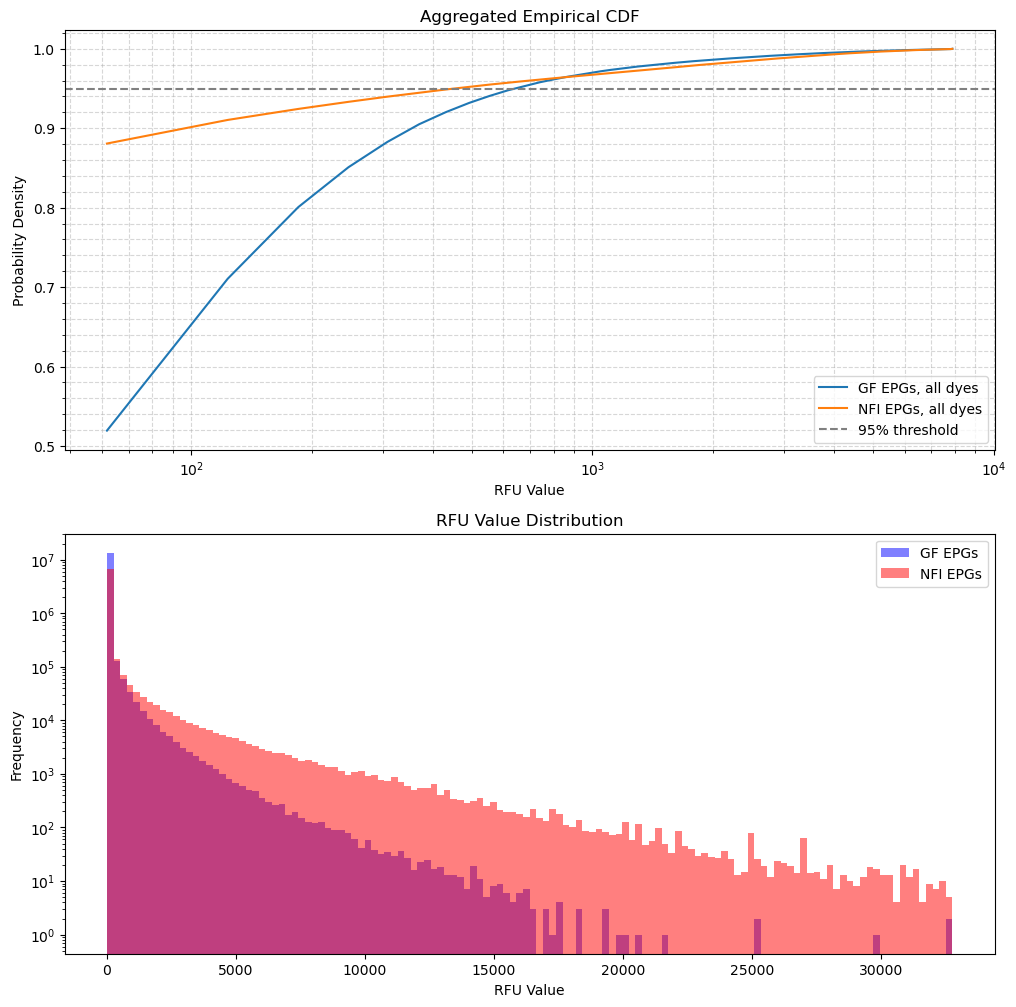

In [ ]:
fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(12, 12), dpi=100)
ax.plot(bin_edges[1:], gf_all_cdf, label=f"GF EPGs, all dyes")
ax.plot(bin_edges[1:], nfi_all_cdf, label=f"NFI EPGs, all dyes")

# plot a straight horizontal line at y=0.95
ax.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
# ax.set_xlim(0, 500)

ax.set_xlabel("RFU Value")
ax.set_ylabel("Probability Density")
ax.set_title("Aggregated Empirical CDF")

ax.legend()
ax.minorticks_on()
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.5)

ax2.hist(gf_rfu_values_flat, bins=bins, color='blue', alpha=0.5, log=True)
ax2.hist(nfi_rfu_values_flat, bins=bins, color='red', alpha=0.5, log=True)
ax2.legend(["GF EPGs", "NFI EPGs"])
ax2.set_xlabel("RFU Value")
ax2.set_ylabel("Frequency")
ax2.set_title("RFU Value Distribution")

fig.savefig(os.path.join(output_dir, "rfu_value_distribution_gf_ppf6.pdf"))

plt.show()

## Plot aggregated CDFs and PDFs per dye

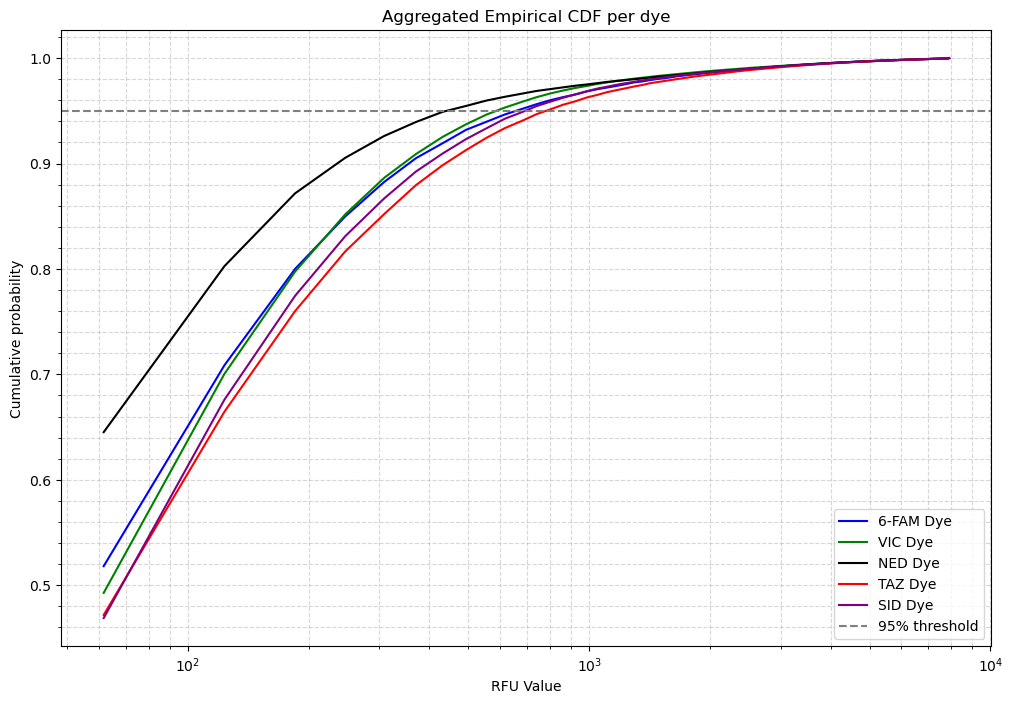

In [110]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
for dye in range(gf_agg_cdf.shape[0]):
    ax.plot(bin_edges[1:], gf_agg_cdf[dye], label=f"{GF_DYE_NAMES[dye]} Dye", color=DNA_CHANNELS[dye])

# plot a straight horizontal line at y=0.95
ax.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
# ax.set_xlim(0, 500)
# ax.set_ylim(0., 0.99)

ax.set_xlabel("RFU Value")
ax.set_ylabel("Cumulative probability")
ax.set_title("Aggregated Empirical CDF per dye")

ax.legend()
ax.minorticks_on()
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()
fig.savefig(os.path.join(output_dir, "empirical_cdf_per_dye.pdf"))

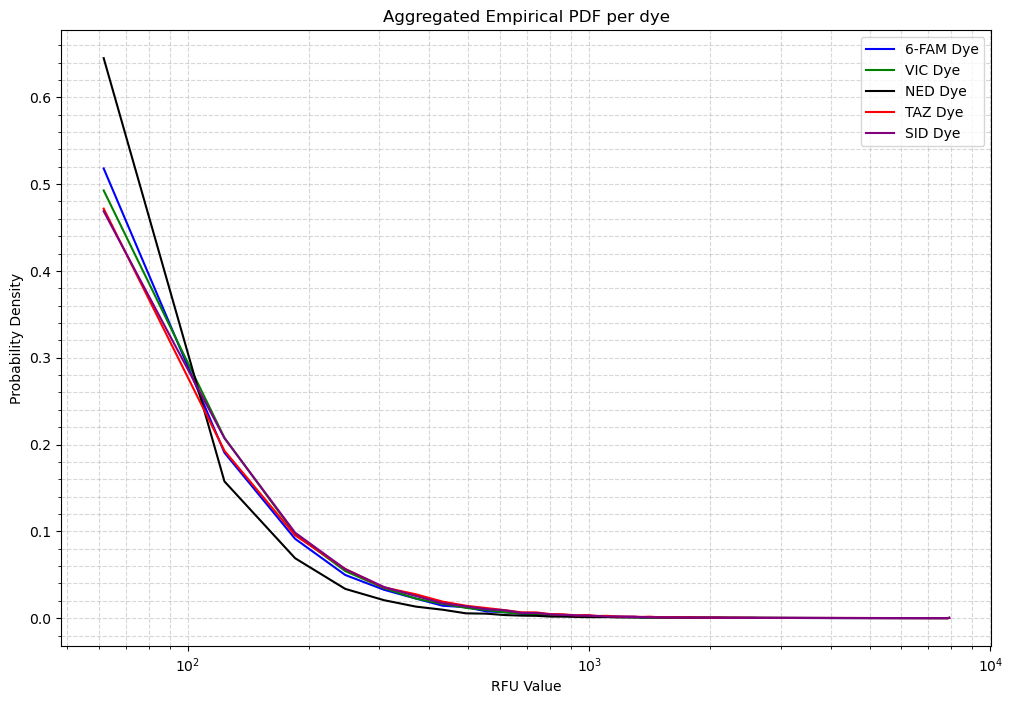

In [111]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
for dye in range(gf_agg_pdf.shape[0]):
    ax.plot(bin_edges[1:],gf_agg_pdf[dye], label=f"{GF_DYE_NAMES[dye]} Dye", color=DNA_CHANNELS[dye])

# ax.set_xlim(left=None, right=10e3)

ax.set_xlabel("RFU Value")
ax.set_ylabel("Probability Density")
ax.set_title("Aggregated Empirical PDF per dye")

ax.legend()
ax.minorticks_on()
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()
fig.savefig(os.path.join(output_dir, "empirical_pdf_per_dye.pdf"))

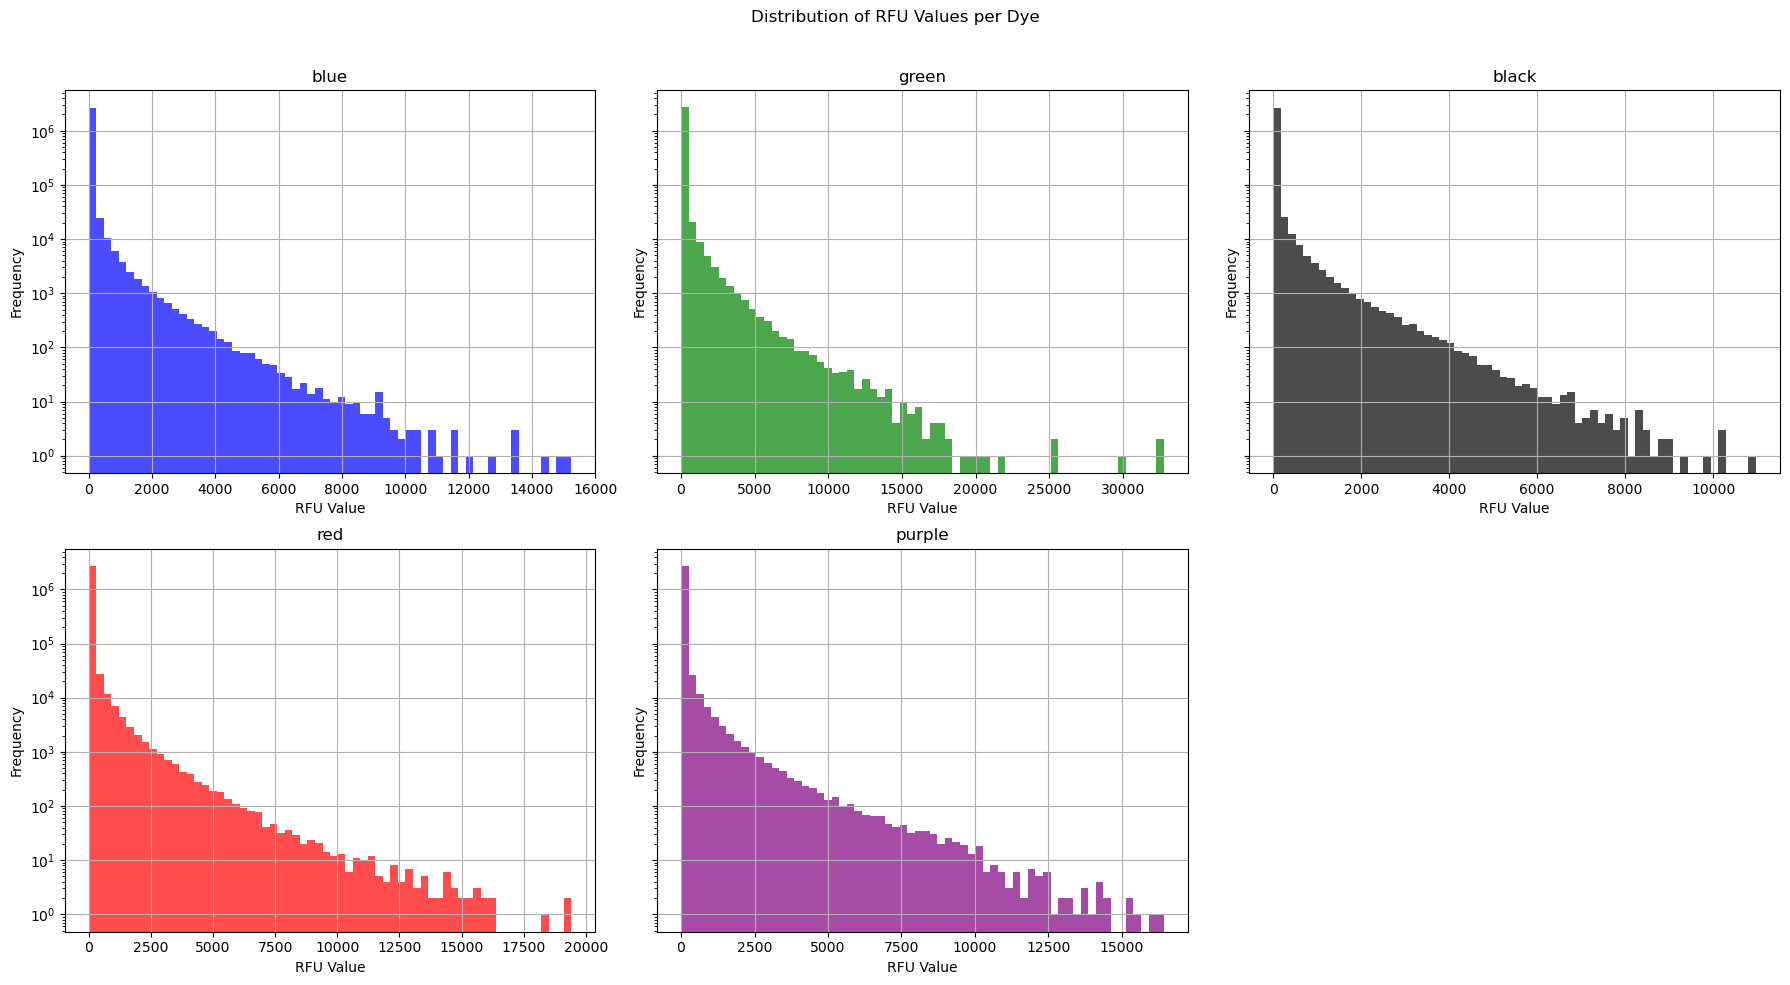

In [112]:
rfu_values_per_dye = gf_rfu_values.squeeze().transpose(1, 0, 2).reshape(5, -1)
rfu_values_per_dye.shape

# min_rfu, max_rfu = rfu_values_flat.min(), rfu_values_flat.max()
# print(f"Min RFU: {min_rfu}, Max RFU: {max_rfu}")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), dpi=100, sharey=True)
axes = axes.flatten()

fig.suptitle("Distribution of RFU Values per Dye")

for idx, dye in enumerate(DNA_CHANNELS[:5]):
    ax = axes[idx]
    ax.hist(rfu_values_per_dye[idx], bins=64, color=dye, alpha=0.7, log=True)
    # ax.tick_params(axis='y', labelleft=True, which="minor")  # force y‐ticks on every subplot
    # ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))

    # ax.set_xlim(min_rfu, max_rfu)
    ax.set_title(dye)
    ax.set_xlabel("RFU Value")
    ax.set_ylabel("Frequency")
    ax.grid(True)
axes[5].axis('off')  # Hide the unused subplot

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust top to make room for the suptitle
plt.show()
fig.savefig(os.path.join(output_dir, "rfu_histogram_per_dye.pdf"))

## Plot Histograms showing where peaks, predictions, and false predictions occur

In [113]:
# Find all allele peaks in the dataset
all_allele_peaks = find_allele_peaks(gf_dataset)
print(f"Total allele peaks found: {len(all_allele_peaks)}")
print(f"Allele peak RFU values in range (35-45): {all_allele_peaks[15:45]}")


predictions_mask = np.array([pred.image > threshold for pred in predictions])  # Assuming binary mask with threshold

# Find all false negative peaks in the dataset
false_negative_peaks = find_false_negative_peaks(gf_dataset, predictions_mask, type="false_negative")
print(f"Total false negative peaks found: {len(false_negative_peaks)}")

# Find all allele peaks in the dataset
all_predicted_peaks = find_predicted_peaks(gf_dataset, predictions_mask)
print(f"Total predicted peaks found: {len(all_predicted_peaks)}")
print(f"Predicted peak RFU values in range (35-45): {all_predicted_peaks[15:45]}")

# Find all false positive peaks in the dataset
false_positive_peaks = find_predicted_peaks_by_type(gf_dataset, predictions_mask, type="false_positive")
print(f"Total false positive peaks found: {len(false_positive_peaks)}")

true_positive_peaks = find_predicted_peaks_by_type(gf_dataset, predictions_mask, type="true_positive")
print(f"Total true positive peaks found: {len(true_positive_peaks)}")

Total allele peaks found: 57861
Allele peak RFU values in range (35-45): [ 54 195 384 225 315 321 129 165 210  99 123 285 120  57 246 144   9 201
  15  54  57 153 111 189 333  51  30 471 471  18]
Total false negative peaks found: 19767
Total predicted peaks found: 46275
Predicted peak RFU values in range (35-45): [285 120 246 144 201  57 159 111 189 333 471 471 480 384  99 315 183 234
 270 342 432 390 210 264 162 507 276 183 168  57]
Total false positive peaks found: 8020
Total true positive peaks found: 38255
Total false negative peaks found: 19767
Total predicted peaks found: 46275
Predicted peak RFU values in range (35-45): [285 120 246 144 201  57 159 111 189 333 471 471 480 384  99 315 183 234
 270 342 432 390 210 264 162 507 276 183 168  57]
Total false positive peaks found: 8020
Total true positive peaks found: 38255


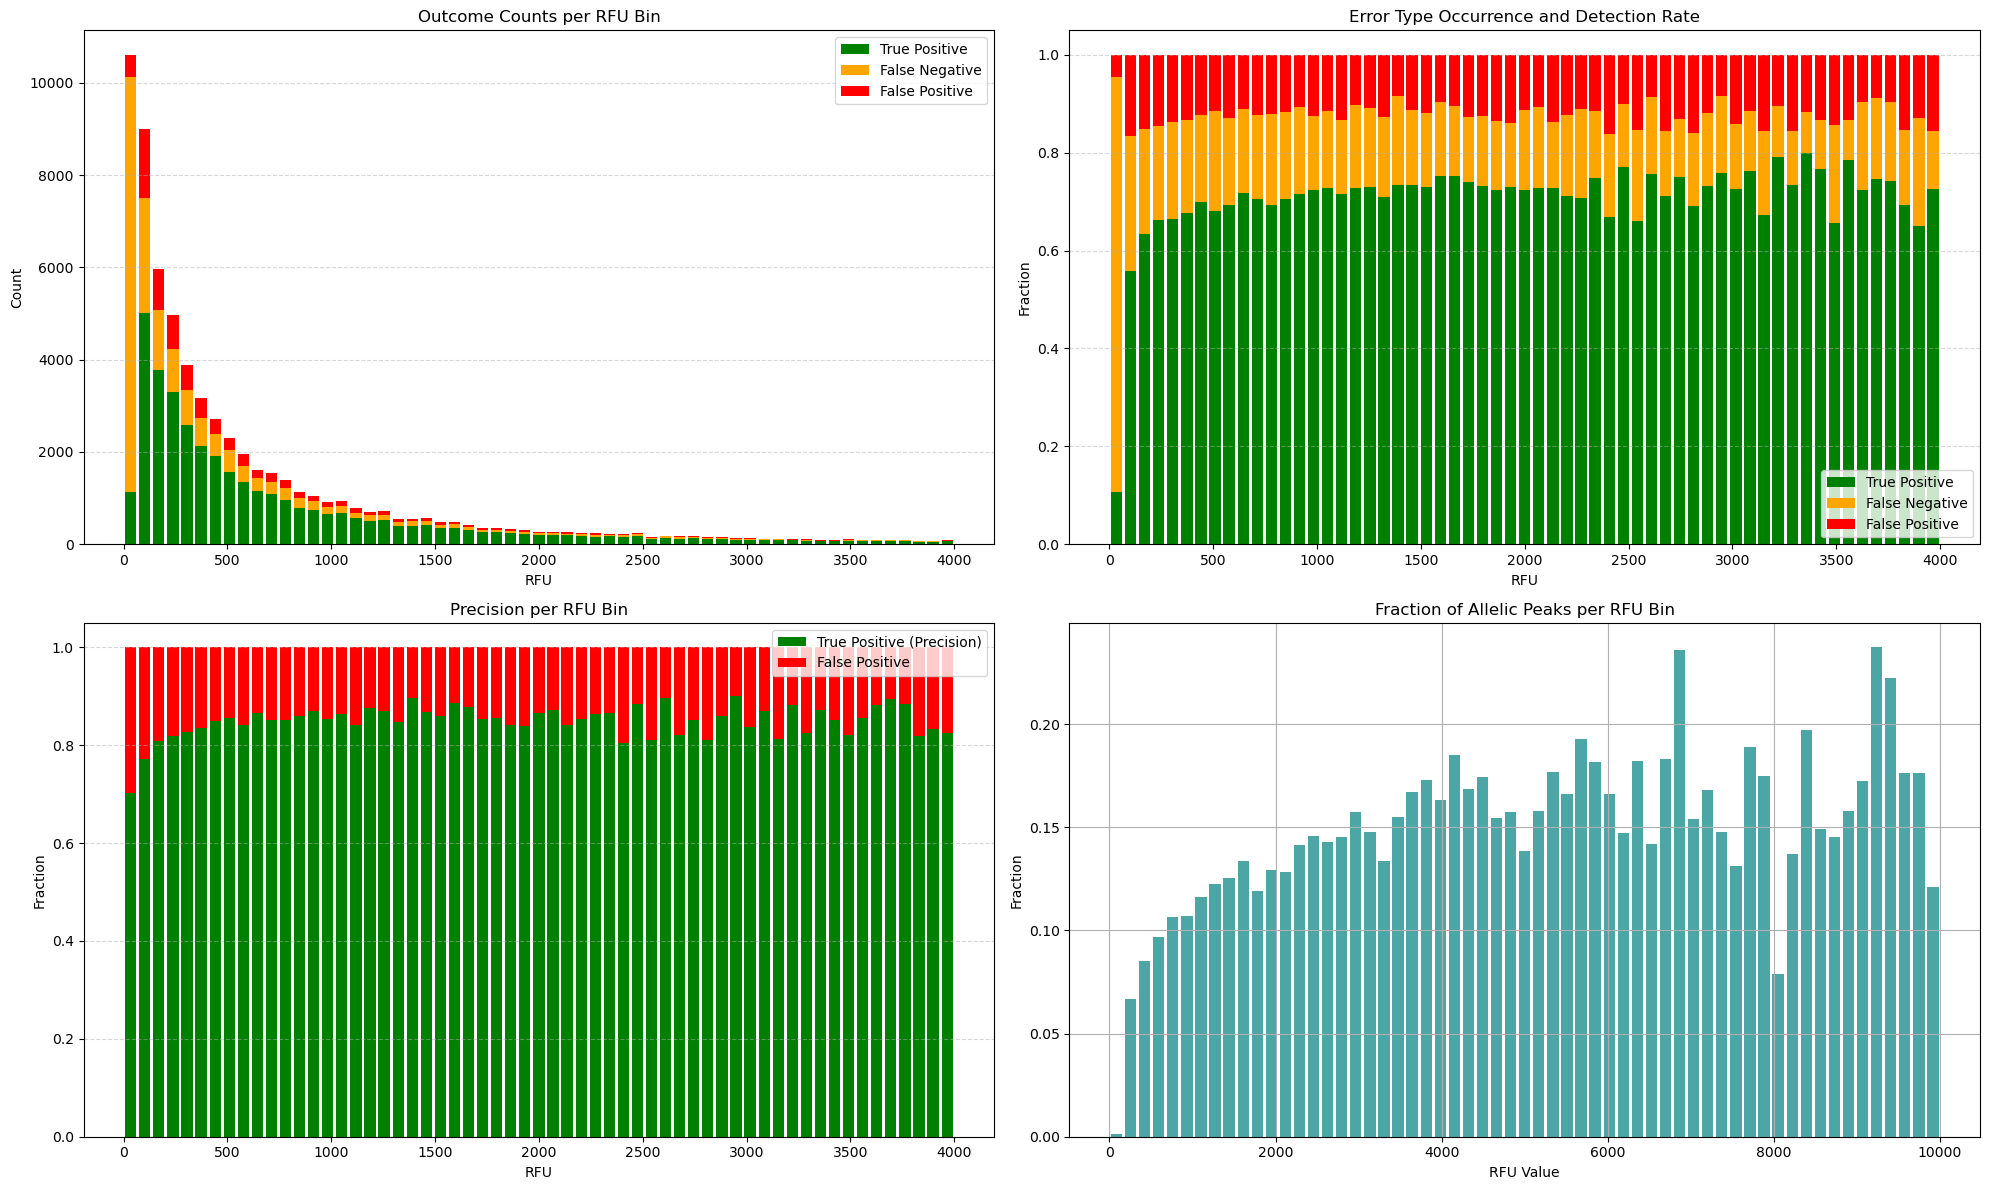

In [114]:
ls_bins = np.linspace(0, 4000, 60)
tp_hist, _ = np.histogram(true_positive_peaks, bins=ls_bins)
fp_hist, _ = np.histogram(false_positive_peaks, bins=ls_bins)
fn_hist, _ = np.histogram(false_negative_peaks, bins=ls_bins)

bar_width = (ls_bins[1] - ls_bins[0]) * 0.8
bin_centers = (ls_bins[:-1] + ls_bins[1:]) / 2

tp_fn = tp_hist + fn_hist
totals = tp_hist + fn_hist + fp_hist
totals_safe = np.where(totals == 0, 1, totals)
tp_norm = tp_hist / totals_safe
fn_norm = fn_hist / totals_safe
fp_norm = fp_hist / totals_safe

tp_fp = tp_hist + fp_hist
tp_fp_safe = np.where(tp_fp == 0, 1, tp_fp)
tp_pred_norm = tp_hist / tp_fp_safe
fp_pred_norm = fp_hist / tp_fp_safe



fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=100)
axs = axs.flatten()

# 1. Absolute counts
axs[0].bar(bin_centers, tp_hist, width=bar_width, label='True Positive', color='green')
axs[0].bar(bin_centers, fn_hist, width=bar_width, bottom=tp_hist, label='False Negative', color='orange')
axs[0].bar(bin_centers, fp_hist, width=bar_width, bottom=tp_hist+fn_hist, label='False Positive', color='red')
axs[0].set_xlabel('RFU')
axs[0].set_ylabel('Count')
axs[0].set_title('Outcome Counts per RFU Bin')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# 2. Normalized by all (TP+FN+FP)
axs[1].bar(bin_centers, tp_norm, width=bar_width, label='True Positive', color='green')
axs[1].bar(bin_centers, fn_norm, width=bar_width, bottom=tp_norm, label='False Negative', color='orange')
axs[1].bar(bin_centers, fp_norm, width=bar_width, bottom=tp_norm+fn_norm, label='False Positive', color='red')
axs[1].set_xlabel('RFU')
axs[1].set_ylabel('Fraction')
axs[1].set_title('Error Type Occurrence and Detection Rate')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# 3. Normalized by predicted positives (TP+FP)
axs[2].bar(bin_centers, tp_pred_norm, width=bar_width, label='True Positive (Precision)', color='green')
axs[2].bar(bin_centers, fp_pred_norm, width=bar_width, bottom=tp_pred_norm, label='False Positive', color='red')
axs[2].set_xlabel('RFU')
axs[2].set_ylabel('Fraction')
axs[2].set_title('Precision per RFU Bin')
axs[2].legend()
axs[2].grid(True, axis='y', linestyle='--', alpha=0.5)



ls_bins = np.linspace(0, 10000, 60)
all_counts, _ = np.histogram(gf_rfu_values_flat, bins=ls_bins)
allele_counts, _ = np.histogram(all_allele_peaks, bins=ls_bins)
all_counts_safe = np.where(all_counts == 0, 1, all_counts)
fraction_allelic = allele_counts / all_counts_safe

bar_width = (ls_bins[1]-ls_bins[0])*0.8
bin_centers = (ls_bins[:-1] + ls_bins[1:]) / 2

# 4. Fraction of allelic peaks per RFU bin
axs[3].bar(bin_centers, fraction_allelic, width=bar_width, color='teal', alpha=0.7)
axs[3].set_xlabel("RFU Value")
axs[3].set_ylabel("Fraction")
axs[3].set_title("Fraction of Allelic Peaks per RFU Bin")
axs[3].grid(True)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(output_dir, "histograms_peaks_predictions.pdf"))

## Rick's stuff

In [115]:
from scipy.stats import kruskal, ks_2samp
from itertools import combinations

def plot_rfu_distributions(dataset: CustomHIDDataset, output_dir: str = "./figures"):
    print("creating plot of rfu values")

    ## plot distribution of RFU values
    data_list, ann_list = zip(*[
        (image.data, image.annotation.image)
        for image in dataset
    ])
    rfu_values  = np.stack(data_list, axis=0)
    print(f"Number of images in dataset: {len(rfu_values)}")
    print(f"Shape of RFU values: {rfu_values.shape}")
    rfu_values_flat = np.concatenate(rfu_values, axis=None)


    groups = [rfu_values_per_dye[i, :] for i in range(rfu_values_per_dye.shape[0])]
    H, p_omni = kruskal(*groups)
    print(f"Kruskal–Wallis H = {H:.3f}, p = {p_omni:.3e}")

    # 2) Pairwise KS tests
    dye_indices = range(rfu_values_per_dye.shape[0])
    for i, j in combinations(dye_indices, 2):
        stat, p = ks_2samp(rfu_values_per_dye[i, :], rfu_values_per_dye[j, :])
        print(f"KS test dye {DNA_CHANNELS[i]} vs {DNA_CHANNELS[j]}: D = {stat:.3f}, p = {p:.3e}")


In [104]:
plot_rfu_distributions(nfi_dataset, output_dir="./figures")

creating plot of rfu values
Number of images in dataset: 350
Shape of RFU values: (350, 5, 4096, 1)
Kruskal–Wallis H = 1636064.532, p = 0.000e+00
KS test dye blue vs green: D = 0.303, p = 0.000e+00
KS test dye blue vs black: D = 0.146, p = 0.000e+00
KS test dye blue vs red: D = 0.157, p = 0.000e+00
KS test dye blue vs purple: D = 0.204, p = 0.000e+00
KS test dye green vs black: D = 0.432, p = 0.000e+00
KS test dye green vs red: D = 0.156, p = 0.000e+00
KS test dye green vs purple: D = 0.110, p = 0.000e+00
KS test dye black vs red: D = 0.303, p = 0.000e+00
KS test dye black vs purple: D = 0.345, p = 0.000e+00
KS test dye red vs purple: D = 0.047, p = 0.000e+00
